In [119]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats

In [120]:
customer_df = pd.read_excel('Bank_Churn_Messy.xlsx', sheet_name= 0)
customer_df = pd.DataFrame(customer_df)
customer_df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary
0,15634602,Hargrave,619,FRA,Female,42.0,2,€101348.88
1,15647311,Hill,608,Spain,Female,41.0,1,€112542.58
2,15619304,Onio,502,French,Female,42.0,8,€113931.57
3,15701354,Boni,699,FRA,Female,39.0,1,€93826.63
4,15737888,Mitchell,850,Spain,Female,43.0,2,€79084.1


### **Check Customer ID Type**

In [121]:
customer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10001 entries, 0 to 10000
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10001 non-null  int64  
 1   Surname          9998 non-null   object 
 2   CreditScore      10001 non-null  int64  
 3   Geography        10001 non-null  object 
 4   Gender           10001 non-null  object 
 5   Age              9998 non-null   float64
 6   Tenure           10001 non-null  int64  
 7   EstimatedSalary  10001 non-null  object 
dtypes: float64(1), int64(3), object(4)
memory usage: 625.2+ KB


In [122]:
account_df = pd.read_excel('Bank_Churn_Messy.xlsx', sheet_name= 1)

In [123]:
account_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10002 entries, 0 to 10001
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   CustomerId      10002 non-null  int64 
 1   Balance         10002 non-null  object
 2   NumOfProducts   10002 non-null  int64 
 3   HasCrCard       10002 non-null  object
 4   Tenure          10002 non-null  int64 
 5   IsActiveMember  10002 non-null  object
 6   Exited          10002 non-null  int64 
dtypes: int64(4), object(3)
memory usage: 547.1+ KB


### **Merge from account to customer on left**

In [124]:
bank_account_df = account_df.merge(customer_df, on='CustomerId', how='left')

In [125]:
account_df['CustomerId'].count()

np.int64(10002)

In [126]:
customer_df['CustomerId'].count()

np.int64(10001)

In [127]:
bank_account_df['CustomerId'].count()

np.int64(10004)

In [128]:
bank_account_df[bank_account_df.duplicated(keep=False)]

,CustomerId,Balance,NumOfProducts,HasCrCard,Tenure_x,IsActiveMember,Exited,Surname,CreditScore,Geography,Gender,Age,Tenure_y,EstimatedSalary
0,15634602,€0.0,1,Yes,2,Yes,1,Hargrave,619,FRA,Female,42.0,2,€101348.88
1,15634602,€0.0,1,Yes,2,Yes,1,Hargrave,619,FRA,Female,42.0,2,€101348.88
10000,15628319,€130142.79,1,No,4,No,0,Walker,792,French,Female,28.0,4,€38190.78
10001,15628319,€130142.79,1,No,4,No,0,Walker,792,French,Female,28.0,4,€38190.78
10002,15628319,€130142.79,1,No,4,No,0,Walker,792,French,Female,28.0,4,€38190.78
10003,15628319,€130142.79,1,No,4,No,0,Walker,792,French,Female,28.0,4,€38190.78


In [129]:
bank_account_df = bank_account_df.drop_duplicates()

In [130]:
bank_account_df[bank_account_df.duplicated(keep=False)]

,CustomerId,Balance,NumOfProducts,HasCrCard,Tenure_x,IsActiveMember,Exited,Surname,CreditScore,Geography,Gender,Age,Tenure_y,EstimatedSalary


In [131]:
bank_account_df.shape

(10000, 14)

In [132]:
(bank_account_df['Tenure_x'] == bank_account_df['Tenure_y']).unique()

array([ True])

In [133]:
bank_account_df.drop(columns=['Tenure_y'], inplace=True)

In [134]:
bank_account_df.columns = bank_account_df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('-', '_')

In [135]:
bank_account_df.columns = bank_account_df.rename(columns={'tenure_x': 'tenure'}).columns

In [136]:
bank_account_df.columns

Index(['customerid', 'balance', 'numofproducts', 'hascrcard', 'tenure',
       'isactivemember', 'exited', 'surname', 'creditscore', 'geography',
       'gender', 'age', 'estimatedsalary'],
      dtype='object')

In [137]:
bank_account_df.dtypes

customerid           int64
balance             object
numofproducts        int64
hascrcard           object
tenure               int64
isactivemember      object
exited               int64
surname             object
creditscore          int64
geography           object
gender              object
age                float64
estimatedsalary     object
dtype: object

In [138]:
bank_account_df['balance'] = bank_account_df['balance'].replace('[€$,]', '', regex=True).astype(float)
bank_account_df['estimatedsalary'] = bank_account_df['estimatedsalary'].replace('[€$,]', '', regex=True).astype(float)


In [139]:
bank_account_df.head()

,customerid,balance,numofproducts,hascrcard,tenure,isactivemember,exited,surname,creditscore,geography,gender,age,estimatedsalary
0,15634602,0.00,1,Yes,2,Yes,1,Hargrave,619,FRA,Female,42.0,101348.88
2,15647311,83807.86,1,Yes,1,Yes,0,Hill,608,Spain,Female,41.0,112542.58
3,15619304,159660.80,3,No,8,No,1,Onio,502,French,Female,42.0,113931.57
4,15701354,0.00,2,No,1,No,0,Boni,699,FRA,Female,39.0,93826.63
5,15737888,125510.82,1,Yes,2,Yes,0,Mitchell,850,Spain,Female,43.0,79084.10


In [140]:
bank_account_df['hascrcard'] = bank_account_df['hascrcard'].map({'Yes': 1, 'No': 0})
bank_account_df['isactivemember'] = bank_account_df['isactivemember'].map({'Yes': 1, 'No': 0})


In [141]:
bank_account_df.dtypes

customerid           int64
balance            float64
numofproducts        int64
hascrcard            int64
tenure               int64
isactivemember       int64
exited               int64
surname             object
creditscore          int64
geography           object
gender              object
age                float64
estimatedsalary    float64
dtype: object

In [142]:
bank_account_df['geography'] = bank_account_df['geography'].str.lower().str.strip()
bank_account_df['gender'] = bank_account_df['gender'].str.lower().str.strip()


In [143]:
bank_account_df.map(type).nunique()

customerid         1
balance            1
numofproducts      1
hascrcard          1
tenure             1
isactivemember     1
exited             1
surname            2
creditscore        1
geography          1
gender             1
age                1
estimatedsalary    1
dtype: int64

In [144]:
bank_account_df.isna().sum()

customerid         0
balance            0
numofproducts      0
hascrcard          0
tenure             0
isactivemember     0
exited             0
surname            3
creditscore        0
geography          0
gender             0
age                3
estimatedsalary    0
dtype: int64

In [145]:
bank_account_df = bank_account_df.dropna(subset=['age'])


In [146]:
bank_account_df.isna().sum()

customerid         0
balance            0
numofproducts      0
hascrcard          0
tenure             0
isactivemember     0
exited             0
surname            0
creditscore        0
geography          0
gender             0
age                0
estimatedsalary    0
dtype: int64

In [147]:
bank_account_df['age'] = bank_account_df['age'].astype(int)


In [148]:
bank_account_df.dtypes

customerid           int64
balance            float64
numofproducts        int64
hascrcard            int64
tenure               int64
isactivemember       int64
exited               int64
surname             object
creditscore          int64
geography           object
gender              object
age                  int64
estimatedsalary    float64
dtype: object

In [149]:
bank_account_df = bank_account_df.drop(columns=['surname', 'customerid'])


In [150]:
bank_account_df.map(type).nunique()

balance            1
numofproducts      1
hascrcard          1
tenure             1
isactivemember     1
exited             1
creditscore        1
geography          1
gender             1
age                1
estimatedsalary    1
dtype: int64

In [151]:
bank_account_df['geography'].unique()

array(['fra', 'spain', 'french', 'france', 'germany'], dtype=object)

In [152]:
bank_account_df['geography'] = bank_account_df['geography'].replace({
    'fra': 'france',
    'french': 'france'
})


In [153]:
bank_account_df.describe()

,balance,numofproducts,hascrcard,tenure,isactivemember,exited,creditscore,age,estimatedsalary
count,9997.000000,9997.000000,9997.000000,9997.000000,9997.000000,9997.000000,9997.000000,9997.000000,9997.000000
mean,76482.679807,1.530359,0.515055,5.013204,0.515055,0.203761,650.545364,38.922077,100092.222656
std,62397.174721,0.581669,0.499798,2.892364,0.499798,0.402814,96.657932,10.489072,57518.775702
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,350.000000,18.000000,11.580000
25%,0.000000,1.000000,0.000000,3.000000,0.000000,0.000000,584.000000,32.000000,50974.570000
50%,97188.620000,1.000000,1.000000,5.000000,1.000000,0.000000,652.000000,37.000000,100236.020000
75%,127642.440000,2.000000,1.000000,7.000000,1.000000,0.000000,718.000000,44.000000,149399.700000
max,250898.090000,4.000000,1.000000,10.000000,1.000000,1.000000,850.000000,92.000000,199992.480000


There are around 35% saving customer accounts as well as Non-saving accounts which are in normal distribution. We will be studying on saving and non saving accounts seperately.
Most customers only use 1 or 2 products. Only few uses more than 2 products. To increase more engagement, we should provide credit card plan. Most customers are long term customers(5years) and the longest is 10 years. New customers such as 0 years and longest(10 years) are quite few.20% of our customers are churners so we need to explore the reason why churn is occuring. There are few customers(6%) with very low credit score(500).Among these customers, 30% of them have high income and balance. We can improve loan using strict policies to prevent churn customers. We can approve suitable low risk loan using strict policies to prevent churn customers. Our target customers are around 32-44 years old. Expanded range is 24-60. Customer age do not impact on saving.

74% of customer income is around 50k to 2 lakhs, 14 % of the customers have an income of 20k to 50k and the rest is below 20k. So, most of out customers have an income of 20k-2lakh. 

50% of our customers are from france. 25% from germany and 25% from spain.

Number of male and female customers are quite balanced.

In [154]:
bank_account_df['geography'].value_counts()

geography
france     5013
germany    2508
spain      2476
Name: count, dtype: int64

In [155]:
bank_account_df[bank_account_df['estimatedsalary'] <= 20000].describe()

,balance,numofproducts,hascrcard,tenure,isactivemember,exited,creditscore,age,estimatedsalary
count,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000
mean,71806.964625,1.529412,0.522312,4.997972,0.522312,0.200811,649.282961,38.641988,9820.001085
std,63053.008010,0.580256,0.499755,2.864450,0.499755,0.400811,98.407100,10.370723,5815.136401
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,395.000000,18.000000,11.580000
25%,0.000000,1.000000,0.000000,2.250000,0.000000,0.000000,580.000000,31.000000,4655.937500
50%,91364.485000,1.000000,1.000000,5.000000,1.000000,0.000000,648.500000,37.000000,9681.900000
75%,126206.862500,2.000000,1.000000,7.000000,1.000000,0.000000,716.000000,43.000000,14711.302500
max,206663.750000,4.000000,1.000000,10.000000,1.000000,1.000000,850.000000,77.000000,19998.310000


In [156]:
bank_account_df['estimatedsalary_group'] = pd.cut(
    bank_account_df['estimatedsalary'],
    bins=[0, 1000, 20000, 50000, 100000, 150000, 200000, 400000],
    labels=['below 1k', '1k - 20k', '20k - 50k', '50k - 1 lakh', '1 lakh - 1.5 lakh', '1.5 lakh - 2 lakh', 'above 2 lakh'],
    right=False
)
bank_account_df['estimatedsalary_group'].value_counts(normalize=True)

estimatedsalary_group
1 lakh - 1.5 lakh    0.255377
50k - 1 lakh         0.253676
1.5 lakh - 2 lakh    0.245574
20k - 50k            0.146744
1k - 20k             0.092728
below 1k             0.005902
above 2 lakh         0.000000
Name: proportion, dtype: float64

In [157]:
bank_account_df['age_group'] = pd.cut(bank_account_df['age'], bins=[17, 20, 23, 31, 44, 60, 120], labels=['18-20', '21-23', '24-31', '32-44', '45-60', 'above 60'])
bank_account_df['age_group'].value_counts()

age_group
32-44       5285
24-31       2047
45-60       1876
above 60     464
21-23        236
18-20         89
Name: count, dtype: int64

In [158]:
bank_account_df[bank_account_df['balance']==0]['age_group'].value_counts(normalize=True)

age_group
32-44       0.535122
24-31       0.217644
45-60       0.165929
above 60    0.046184
21-23       0.025166
18-20       0.009956
Name: proportion, dtype: float64

In [159]:
bank_account_df[bank_account_df['creditscore'] < 500].describe()

,balance,numofproducts,hascrcard,tenure,isactivemember,exited,creditscore,age,estimatedsalary
count,632.000000,632.000000,632.000000,632.000000,632.000000,632.000000,632.000000,632.000000,632.000000
mean,80294.231329,1.515823,0.468354,5.077532,0.468354,0.237342,462.925633,38.908228,103307.478418
std,62792.369008,0.579417,0.499393,2.824839,0.499393,0.425790,30.113033,10.265777,57842.565848
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,350.000000,19.000000,878.870000
25%,0.000000,1.000000,0.000000,3.000000,0.000000,0.000000,445.000000,32.000000,56598.880000
50%,100697.760000,1.000000,0.000000,5.000000,0.000000,0.000000,470.000000,37.000000,101297.595000
75%,131097.260000,2.000000,1.000000,8.000000,1.000000,0.000000,487.000000,44.000000,155828.382500
max,221532.800000,4.000000,1.000000,10.000000,1.000000,1.000000,499.000000,84.000000,199505.530000


In [160]:
bank_account_df[(bank_account_df['estimatedsalary'] >= 100000) &
                (bank_account_df['creditscore'] <= 500)&
                (bank_account_df['balance']>=100000)].describe()

,balance,numofproducts,hascrcard,tenure,isactivemember,exited,creditscore,age,estimatedsalary
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,135248.328982,1.461078,0.413174,5.161677,0.413174,0.227545,462.784431,39.203593,153429.581737
std,23139.782088,0.598678,0.493884,2.929528,0.493884,0.420508,33.468763,10.964092,28450.370264
min,100374.580000,1.000000,0.000000,0.000000,0.000000,0.000000,350.000000,19.000000,100447.530000
25%,117202.445000,1.000000,0.000000,2.000000,0.000000,0.000000,450.500000,32.000000,128002.440000
50%,131286.460000,1.000000,0.000000,6.000000,0.000000,0.000000,470.000000,37.000000,154360.970000
75%,151920.915000,2.000000,1.000000,8.000000,1.000000,0.000000,487.500000,45.000000,177213.265000
max,221532.800000,4.000000,1.000000,10.000000,1.000000,1.000000,500.000000,74.000000,198714.290000


In [161]:
bank_account_df['hascrcard'].value_counts(normalize=True)

hascrcard
1    0.515055
0    0.484945
Name: proportion, dtype: float64

In [162]:
bank_account_df[(bank_account_df['hascrcard'] == 0) & (bank_account_df['exited'] == 0)].describe()

,balance,numofproducts,hascrcard,tenure,isactivemember,exited,creditscore,age,estimatedsalary
count,3546.000000,3546.000000,3546.0,3546.000000,3546.0,3546.0,3546.000000,3546.000000,3546.000000
mean,72035.243421,1.554992,0.0,5.127750,0.0,0.0,648.907501,35.470671,100342.685237
std,63300.623286,0.507150,0.0,2.864851,0.0,0.0,96.228741,7.147478,57433.884371
min,0.000000,1.000000,0.0,0.000000,0.0,0.0,408.000000,18.000000,96.270000
25%,0.000000,1.000000,0.0,3.000000,0.0,0.0,582.250000,31.000000,50956.250000
50%,91776.980000,2.000000,0.0,5.000000,0.0,0.0,650.000000,35.000000,100168.240000
75%,127059.967500,2.000000,0.0,8.000000,0.0,0.0,716.000000,40.000000,148944.647500
max,221532.800000,3.000000,0.0,10.000000,0.0,0.0,850.000000,77.000000,199992.480000


In [163]:
bank_account_df[(bank_account_df['hascrcard'] == 0) & (bank_account_df['exited'] == 0)&
                (bank_account_df['creditscore'] >= 700) & (bank_account_df['estimatedsalary'] >= 100000) &
                (bank_account_df['balance']>=100000)].describe()

,balance,numofproducts,hascrcard,tenure,isactivemember,exited,creditscore,age,estimatedsalary
count,243.000000,243.000000,243.0,243.000000,243.0,243.0,243.000000,243.000000,243.000000
mean,130852.710576,1.349794,0.0,5.045267,0.0,0.0,760.777778,36.094650,151929.929630
std,20663.477546,0.486459,0.0,2.818550,0.0,0.0,45.218569,7.638209,29394.290828
min,100054.770000,1.000000,0.0,0.000000,0.0,0.0,700.000000,18.000000,100137.700000
25%,115011.695000,1.000000,0.0,3.000000,0.0,0.0,722.000000,31.000000,125683.170000
50%,126875.620000,1.000000,0.0,5.000000,0.0,0.0,756.000000,36.000000,152039.670000
75%,144389.910000,2.000000,0.0,7.000000,0.0,0.0,788.000000,41.000000,177038.145000
max,191775.650000,3.000000,0.0,10.000000,0.0,0.0,850.000000,68.000000,199484.960000


In [164]:
len(bank_account_df[(bank_account_df['hascrcard'] == 0) & 
                    (bank_account_df['exited'] == 0)&
                    (bank_account_df['creditscore'] >= 700) & 
                    (bank_account_df['estimatedsalary'] >= 100000) &
                    (bank_account_df['balance']>=100000)])/len(bank_account_df)*100

2.43072921876563

In [165]:
potential_active_customers = bank_account_df[(bank_account_df['hascrcard'] == 0) & (bank_account_df['exited'] == 0)&
                (bank_account_df['creditscore'] >= 700) & (bank_account_df['estimatedsalary'] >= 100000) &
                (bank_account_df['balance']>=100000)]

In [166]:
len(potential_active_customers)/len(bank_account_df)*100

2.43072921876563

In [167]:
pd.crosstab(potential_active_customers['geography'],potential_active_customers['gender'], rownames=['Geography'], colnames= ['Gender'])

Gender,female,male
Geography,,
france,42,74
germany,50,37
spain,17,23


### VALUABLE INSIGHTS 
- We should improve the **active rate** of this **2.4%(inactivce)** of the customers who have high credit score, good salary as well as balance by providing a **CREDIT CARD**.
- Having a credit card and being an active member has a direct correlation.
- We should focus on **France, Germany**. **Spain** has fewer potential customers but should consider as well.
- France more male, Germany more female and Spain more male. **Not significant** 

<Axes: xlabel='balance', ylabel='Count'>

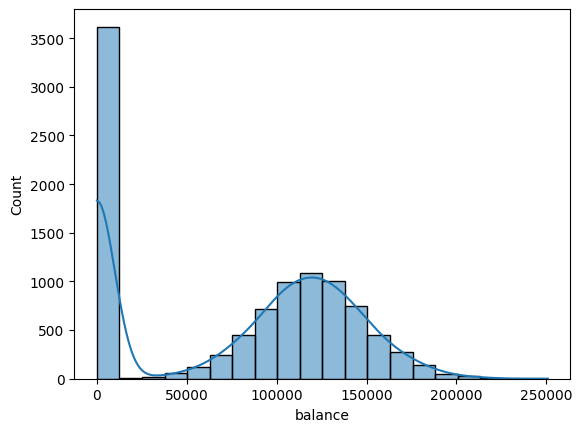

In [168]:
sns.histplot(data=bank_account_df, x='balance', bins=20, kde=True)

In [169]:
bank_account_df.describe()

,balance,numofproducts,hascrcard,tenure,isactivemember,exited,creditscore,age,estimatedsalary
count,9997.000000,9997.000000,9997.000000,9997.000000,9997.000000,9997.000000,9997.000000,9997.000000,9997.000000
mean,76482.679807,1.530359,0.515055,5.013204,0.515055,0.203761,650.545364,38.922077,100092.222656
std,62397.174721,0.581669,0.499798,2.892364,0.499798,0.402814,96.657932,10.489072,57518.775702
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,350.000000,18.000000,11.580000
25%,0.000000,1.000000,0.000000,3.000000,0.000000,0.000000,584.000000,32.000000,50974.570000
50%,97188.620000,1.000000,1.000000,5.000000,1.000000,0.000000,652.000000,37.000000,100236.020000
75%,127642.440000,2.000000,1.000000,7.000000,1.000000,0.000000,718.000000,44.000000,149399.700000
max,250898.090000,4.000000,1.000000,10.000000,1.000000,1.000000,850.000000,92.000000,199992.480000


In [170]:
no_saving_customers =  bank_account_df[bank_account_df['balance'] == 0]
saving_customers = bank_account_df[bank_account_df['balance'] > 0]  

In [171]:
no_saving_customers.describe()

,balance,numofproducts,hascrcard,tenure,isactivemember,exited,creditscore,age,estimatedsalary
count,3616.0,3616.000000,3616.000000,3616.000000,3616.000000,3616.000000,3616.000000,3616.000000,3616.000000
mean,0.0,1.784845,0.517699,5.072179,0.517699,0.138274,649.483684,38.436670,98988.773327
std,0.0,0.496352,0.499756,2.860721,0.499756,0.345235,96.154226,10.492907,57737.961619
min,0.0,1.000000,0.000000,0.000000,0.000000,0.000000,350.000000,18.000000,90.070000
25%,0.0,1.750000,0.000000,3.000000,0.000000,0.000000,583.000000,31.000000,49495.975000
50%,0.0,2.000000,1.000000,5.000000,1.000000,0.000000,651.000000,37.000000,98619.915000
75%,0.0,2.000000,1.000000,7.000000,1.000000,0.000000,717.000000,43.000000,148370.202500
max,0.0,4.000000,1.000000,10.000000,1.000000,1.000000,850.000000,88.000000,199992.480000


In [172]:
pd.crosstab(bank_account_df['hascrcard'],bank_account_df['exited'], rownames=['Has Credit Card'], colnames=['Churn Status'])

Churn Status,0,1
Has Credit Card,,
0,3546,1302
1,4414,735


In [173]:
pd.crosstab(no_saving_customers['hascrcard'],bank_account_df['exited'], rownames=['Has Credit Card'], colnames=['Churn Status'])

Churn Status,0,1
Has Credit Card,,
0,1424,320
1,1692,180


In [174]:
no_saving_customers[(no_saving_customers['creditscore'] >= 700) &
                   (no_saving_customers['estimatedsalary'] >= 100000) &
                     (no_saving_customers['exited'] == 0)].describe()

,balance,numofproducts,hascrcard,tenure,isactivemember,exited,creditscore,age,estimatedsalary
count,480.0,480.000000,480.000000,480.000000,480.000000,480.0,480.000000,480.000000,480.000000
mean,0.0,1.864583,0.545833,5.154167,0.545833,0.0,758.675000,37.010417,149730.417167
std,0.0,0.371753,0.498414,2.825692,0.498414,0.0,44.677908,10.027202,28384.669531
min,0.0,1.000000,0.000000,0.000000,0.000000,0.0,700.000000,19.000000,100101.060000
25%,0.0,2.000000,0.000000,3.000000,0.000000,0.0,722.000000,30.000000,124458.567500
50%,0.0,2.000000,1.000000,5.000000,1.000000,0.0,748.000000,36.000000,149182.200000
75%,0.0,2.000000,1.000000,8.000000,1.000000,0.0,791.250000,41.000000,174432.127500
max,0.0,3.000000,1.000000,10.000000,1.000000,0.0,850.000000,85.000000,199775.670000


In [175]:
potential_customers = no_saving_customers[(no_saving_customers['creditscore'] >= 700) &
                   (no_saving_customers['estimatedsalary'] >= 100000) &
                     (no_saving_customers['exited'] == 0)]

In [176]:
potential_customers['age_group'].value_counts()

age_group
32-44       252
24-31       132
45-60        58
above 60     20
21-23        11
18-20         7
Name: count, dtype: int64

Among no saving customers, there are over 10% of potential customers around 480 who have high credit score, high income by offering saving plan and there are also 50% of potential customers don't have credit card. By provding credit card, increase engagement and saving. Their age segments are 24-60 similar to overall customer age segment. It is better if we get customer demographic and jobs like self employed or staff and their company data so we can provide more valuable and specific customer segment to marketing team. Our potential customers are from France and Spain and we can provide localized programs.

In [177]:
potential_customers['geography'].value_counts()

geography
france    333
spain     147
Name: count, dtype: int64

In [178]:
saving_customers.describe()

,balance,numofproducts,hascrcard,tenure,isactivemember,exited,creditscore,age,estimatedsalary
count,6381.000000,6381.000000,6381.000000,6381.000000,6381.000000,6381.000000,6381.000000,6381.000000,6381.000000
mean,119824.063631,1.386146,0.513556,4.979784,0.513556,0.240871,651.146999,39.197148,100717.527902
std,30098.566614,0.577061,0.499855,2.909836,0.499855,0.427646,96.944568,10.477742,57389.308806
min,3768.690000,1.000000,0.000000,0.000000,0.000000,0.000000,350.000000,18.000000,11.580000
25%,100169.510000,1.000000,0.000000,2.000000,0.000000,0.000000,584.000000,32.000000,51721.520000
50%,119825.750000,1.000000,1.000000,5.000000,1.000000,0.000000,652.000000,38.000000,101141.280000
75%,139496.350000,2.000000,1.000000,8.000000,1.000000,0.000000,718.000000,44.000000,149599.620000
max,250898.090000,4.000000,1.000000,10.000000,1.000000,1.000000,850.000000,92.000000,199970.740000


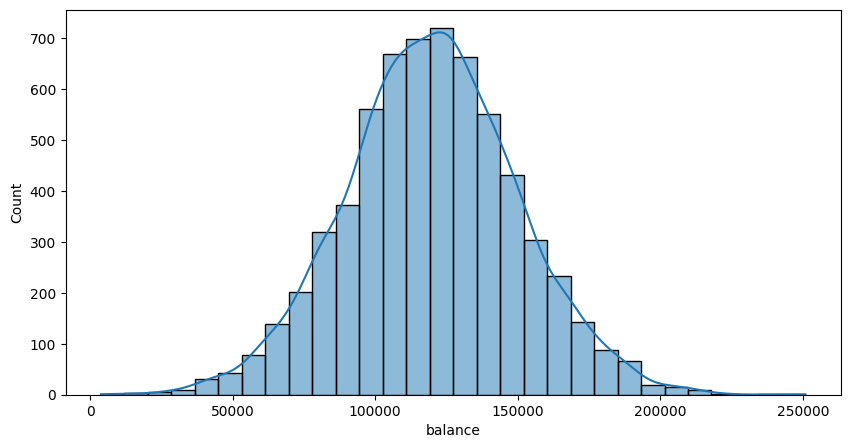

In [179]:
plt.figure(figsize=(10,5))
sns.histplot(data=saving_customers, x='balance', bins=30, kde=True)
plt.show()

In [180]:
saving_customers.groupby('geography')['balance'].describe().T

geography,france,germany,spain
count,2596.000000,2508.000000,1277.000000
mean,119927.765597,119721.495993,119814.689577
std,31732.792620,27023.944318,32355.361987
min,3768.690000,27288.430000,12459.190000
25%,98440.985000,102796.830000,98052.660000
50%,120135.155000,119699.425000,119670.180000
75%,141143.112500,137499.442500,140355.600000
max,238387.560000,214346.960000,250898.090000


In [181]:
saving_customers.groupby('geography')['estimatedsalary'].describe().T

geography,france,germany,spain
count,2596.000000,2508.000000,1277.000000
mean,100625.034653,101113.804322,100127.278262
std,56941.502946,58274.627472,56576.974434
min,123.070000,11.580000,479.540000
25%,52575.295000,50982.392500,52341.150000
50%,100507.170000,102412.865000,101139.300000
75%,149563.020000,151099.517500,146738.830000
max,199929.170000,199970.740000,199953.330000


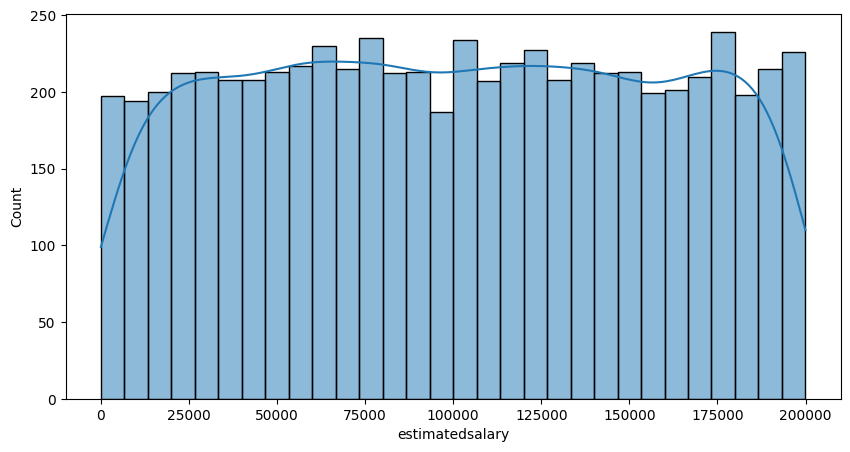

In [182]:
plt.figure(figsize=(10,5))
sns.histplot(data=saving_customers, x='estimatedsalary', bins=30, kde=True)
plt.show()

There are no different saving and income behavior on geography. Saving customers have consistent saving range although they don't have same income behavior. Different customers have flat different incomes.
Most customers save between 50000 and 200000. There are also few more customers that save more than 200000.

In [183]:
saving_customers[saving_customers['hascrcard'] == 0].describe()

,balance,numofproducts,hascrcard,tenure,isactivemember,exited,creditscore,age,estimatedsalary
count,3104.000000,3104.000000,3104.0,3104.000000,3104.0,3104.000000,3104.000000,3104.000000,3104.000000
mean,120458.891749,1.389820,0.0,5.105992,0.0,0.316366,648.048325,38.518041,101521.312345
std,29826.525657,0.593856,0.0,2.892985,0.0,0.465133,98.581647,9.167419,57537.858771
min,3768.690000,1.000000,0.0,0.000000,0.0,0.000000,350.000000,18.000000,91.750000
25%,100878.457500,1.000000,0.0,3.000000,0.0,0.000000,580.750000,32.000000,53860.310000
50%,120102.920000,1.000000,0.0,5.000000,0.0,0.000000,650.000000,38.000000,101028.225000
75%,139682.880000,2.000000,0.0,8.000000,0.0,1.000000,717.000000,44.000000,150248.532500
max,222267.630000,4.000000,0.0,10.000000,0.0,1.000000,850.000000,84.000000,199970.740000


In [184]:
saving_customers[(saving_customers['hascrcard'] == 0) & (saving_customers['exited'] == 0)].describe()

,balance,numofproducts,hascrcard,tenure,isactivemember,exited,creditscore,age,estimatedsalary
count,2122.000000,2122.000000,2122.0,2122.000000,2122.0,2122.0,2122.000000,2122.000000,2122.000000
mean,120375.576423,1.367578,0.0,5.128181,0.0,0.0,649.506126,35.594251,101300.898431
std,29587.741291,0.486154,0.0,2.861500,0.0,0.0,96.804737,7.157738,57375.056036
min,14262.800000,1.000000,0.0,0.000000,0.0,0.0,410.000000,18.000000,143.340000
25%,99789.590000,1.000000,0.0,3.000000,0.0,0.0,583.000000,31.000000,53704.617500
50%,120570.240000,1.000000,0.0,5.000000,0.0,0.0,651.000000,35.000000,100565.590000
75%,139947.935000,2.000000,0.0,8.000000,0.0,0.0,717.000000,40.000000,149295.360000
max,221532.800000,3.000000,0.0,10.000000,0.0,0.0,850.000000,77.000000,199970.740000


In [185]:
potential_saving_customers = saving_customers[(saving_customers['balance'] > 100000) &
                 (saving_customers['creditscore'] >= 700) &
                 (saving_customers['estimatedsalary'] > 100000) &
                 (saving_customers['hascrcard'] == 0) & 
                 (saving_customers['exited'] == 0)]

In [186]:
potential_saving_customers.describe()

,balance,numofproducts,hascrcard,tenure,isactivemember,exited,creditscore,age,estimatedsalary
count,243.000000,243.000000,243.0,243.000000,243.0,243.0,243.000000,243.000000,243.000000
mean,130852.710576,1.349794,0.0,5.045267,0.0,0.0,760.777778,36.094650,151929.929630
std,20663.477546,0.486459,0.0,2.818550,0.0,0.0,45.218569,7.638209,29394.290828
min,100054.770000,1.000000,0.0,0.000000,0.0,0.0,700.000000,18.000000,100137.700000
25%,115011.695000,1.000000,0.0,3.000000,0.0,0.0,722.000000,31.000000,125683.170000
50%,126875.620000,1.000000,0.0,5.000000,0.0,0.0,756.000000,36.000000,152039.670000
75%,144389.910000,2.000000,0.0,7.000000,0.0,0.0,788.000000,41.000000,177038.145000
max,191775.650000,3.000000,0.0,10.000000,0.0,0.0,850.000000,68.000000,199484.960000


In [187]:
770/2122

0.36286522148916117

In [188]:
potential_saving_customers['geography'].value_counts()

geography
france     116
germany     87
spain       40
Name: count, dtype: int64

In [189]:
potential_saving_customers['gender'].value_counts()

gender
male      134
female    109
Name: count, dtype: int64

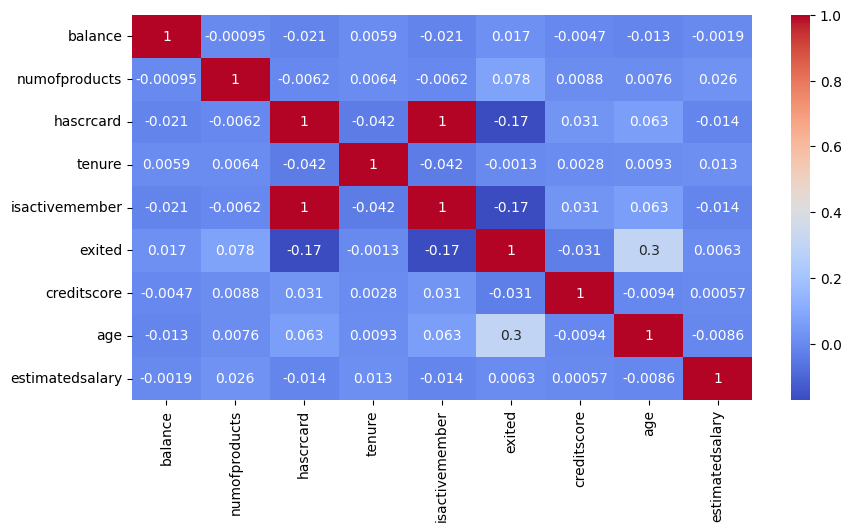

In [190]:
numerical_columns = saving_customers.select_dtypes(include=np.number).columns
saving_customer_corr = saving_customers[numerical_columns].corr()

plt.figure(figsize=(10, 5))
sns.heatmap(saving_customer_corr, annot=True, cmap='coolwarm')
plt.show()

In [191]:
pd.crosstab(saving_customers['age_group'], saving_customers['exited'], rownames=['Age Group'], colnames=['Churn Status'])

Churn Status,0,1
Age Group,,
18-20,50,3
21-23,129,16
24-31,1139,121
32-44,2736,614
45-60,584,692
above 60,206,91


In [192]:
saving_customers.groupby('exited').describe().T.style.set_sticky()

### Churn Insights

- Customers who churn tend to have **higher balances** and **higher estimated salaries** than non-churners.  
- Churners generally have **lower credit scores** compared to non-churners.  
- Customers aged **40 to 60** show a higher likelihood of churning.  
- **Tenure (customer duration)** does not appear to have a strong relationship with churn.

### Recommendation

- Prioritize **credit-card-related offers** for high-risk customers in the **40-60 age group**. 
- Apply **stricter loan eligibility criteria** for this segment to reduce churn risk.

In [193]:
bank_account_df['saving'] = bank_account_df['balance'].apply(lambda x:1 if x>0 else 0)

In [194]:
bank_account_df.columns

Index(['balance', 'numofproducts', 'hascrcard', 'tenure', 'isactivemember',
       'exited', 'creditscore', 'geography', 'gender', 'age',
       'estimatedsalary', 'estimatedsalary_group', 'age_group', 'saving'],
      dtype='object')

<Axes: xlabel='balance', ylabel='Count'>

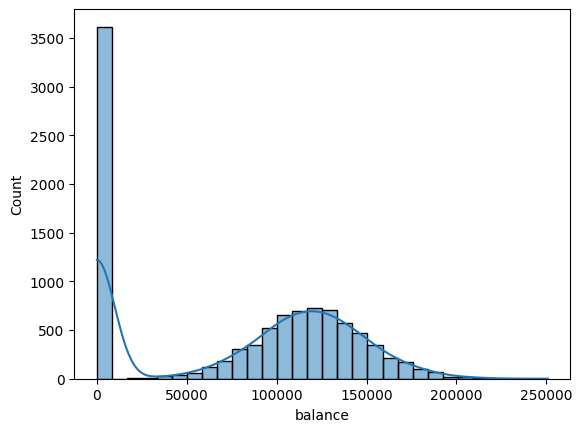

In [195]:
sns.histplot(bank_account_df['balance'], bins=30, kde=True)

In [196]:
bank_account_df['saving_group'] = pd.cut(bank_account_df['balance'], bins=[-1, 0, 50000, 100000, 150000, 200000, 300000], labels=['no saving', '0-50k', '50k-1 lakh', '1 lakh - 1.5 lakh', '1.5 lakh - 2 lakh', 'above 2 lakh'])

In [197]:
bank_account_df['saving_group'].value_counts()

saving_group
1 lakh - 1.5 lakh    3828
no saving            3616
50k-1 lakh           1509
1.5 lakh - 2 lakh     935
0-50k                  75
above 2 lakh           34
Name: count, dtype: int64

<Axes: xlabel='creditscore', ylabel='Count'>

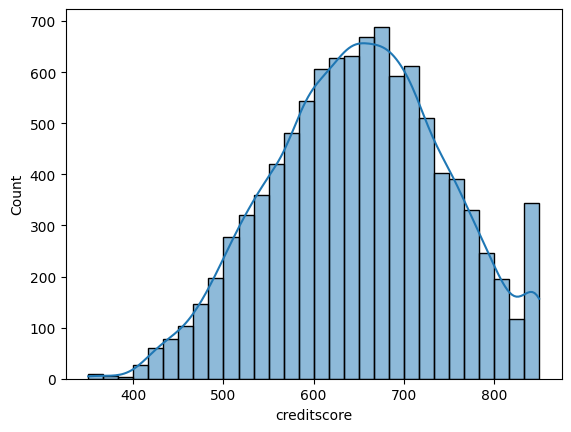

In [198]:
sns.histplot(bank_account_df['creditscore'], bins=30, kde=True)

In [199]:
bank_account_df['creditscore_group'] = pd.cut(
    bank_account_df['creditscore'],
    bins=[-np.inf, 650, 700, 800, np.inf],
    labels=['below 650', '650-700', '700-800', 'above 800'],
    include_lowest=True
)

In [200]:
bank_account_df['creditscore_group'].value_counts()

creditscore_group
below 650    4935
700-800      2471
650-700      1946
above 800     645
Name: count, dtype: int64

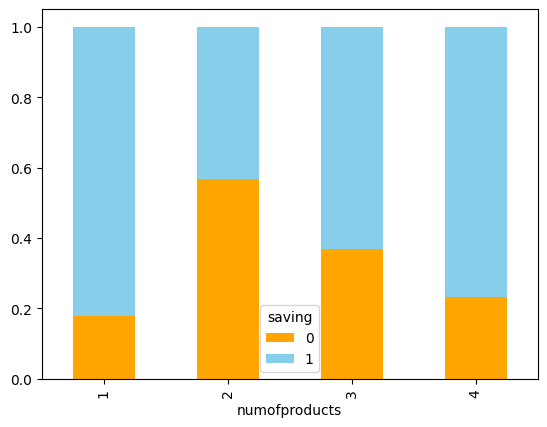

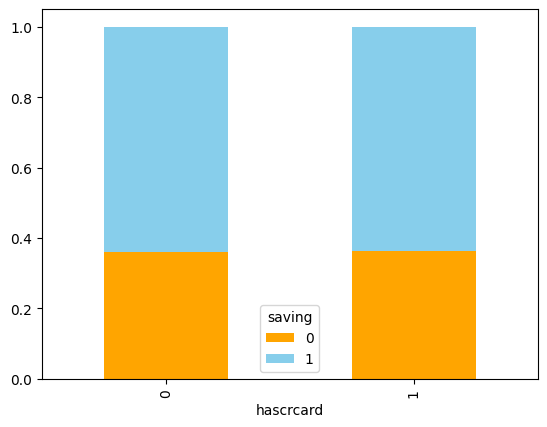

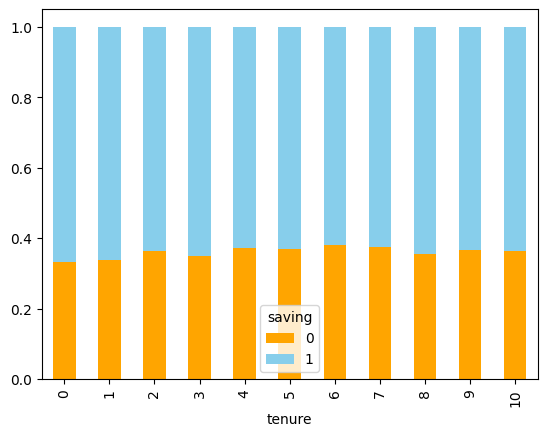

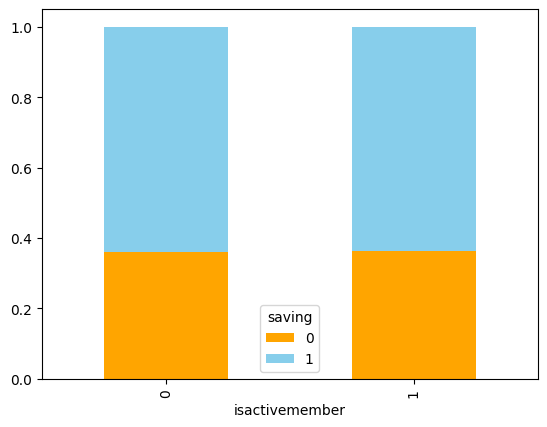

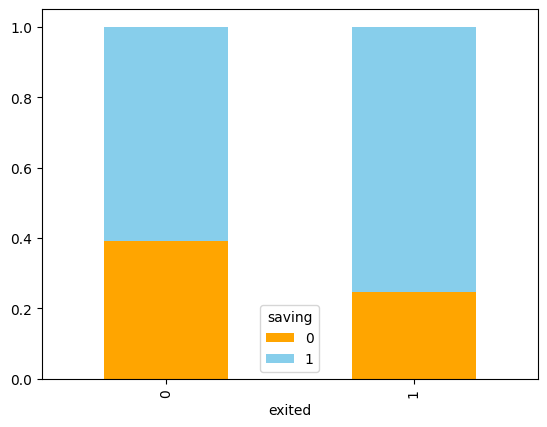

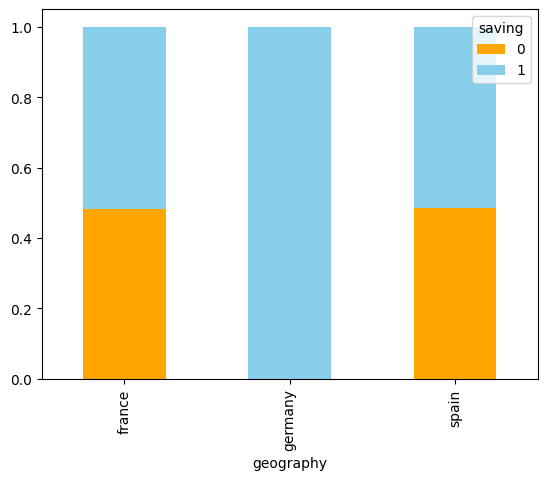

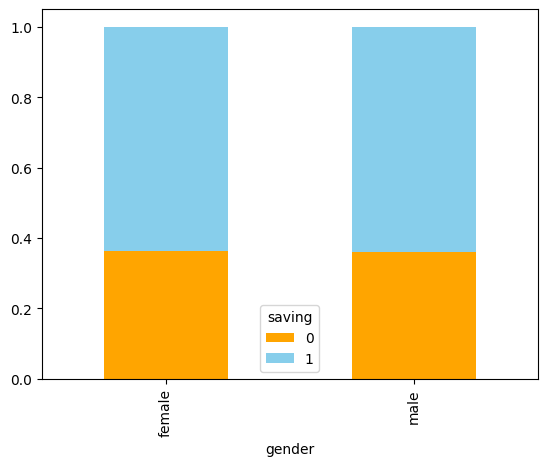

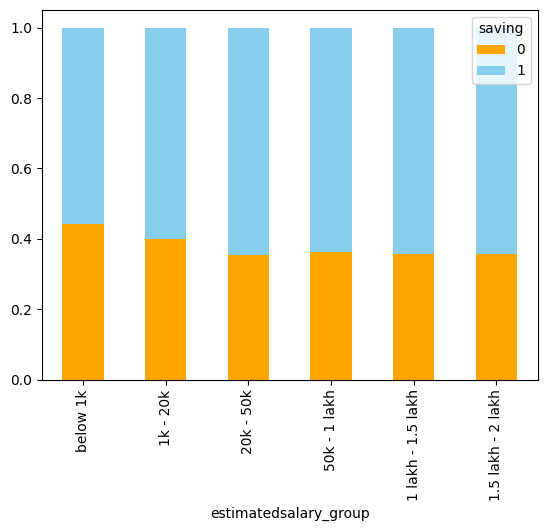

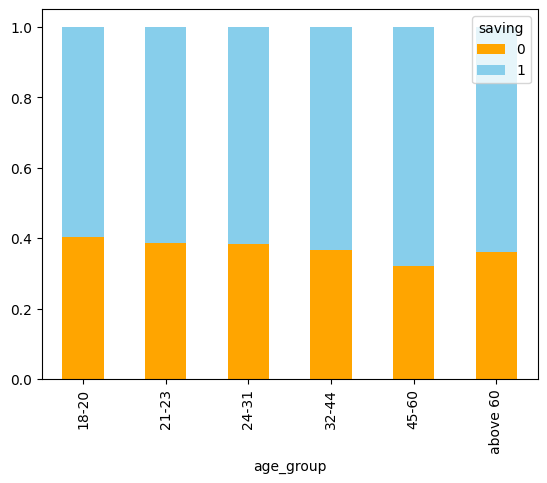

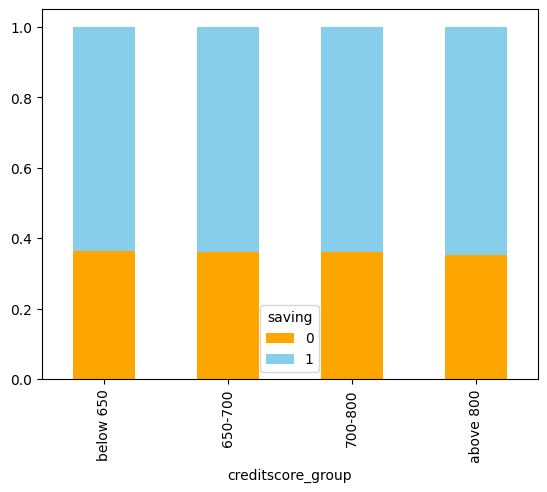

In [201]:
saving_categorical_columns = [
    'numofproducts', 'hascrcard', 'tenure', 'isactivemember',
    'exited', 'geography', 'gender', 'estimatedsalary_group', 'age_group',
    'creditscore_group'
]

for col in saving_categorical_columns:
    ct = pd.crosstab(bank_account_df[col], bank_account_df['saving'], normalize='index')
    ct.plot(kind='bar', stacked=True, color=['orange', 'skyblue'])
    plt.show()

Around 38% of France and Spain customers are no saving customers and all germany customers are saving customers.

In [202]:
pd.crosstab(potential_saving_customers['geography'],potential_saving_customers['gender'], rownames=['Geography'], colnames=['Gender'], normalize='index')*100

Gender,female,male
Geography,,
france,36.206897,63.793103
germany,57.471264,42.528736
spain,42.500000,57.500000


In [203]:
bank_account_df.groupby('geography').describe().T.style.set_sticky()

Customers from Germany has a higher churn rate. They get higher salary and thus leading to having more money than other countries in saving account. We need to run regression test to evaluate what are the factors that has more influence on the churn rate.

In saving customers, there are 243 customers who have high balance, credit score and estimated salaries. Most of customers are located in France and Germany. In france and spain, there are higher male customers but in Germany, there are more female customers. 

In saving customers, there are 2122 customers who do not have a credit card. Out of these, 770 customers are active members (have not exited). This indicates that approximately 36.3% of the saving customers without a credit card are active members.

In [204]:
saving_churn_customer_df = saving_customers[saving_customers['exited'] == 1]
saving_non_churn_customer_df = saving_customers[saving_customers['exited'] == 0]

<Axes: xlabel='balance', ylabel='Count'>

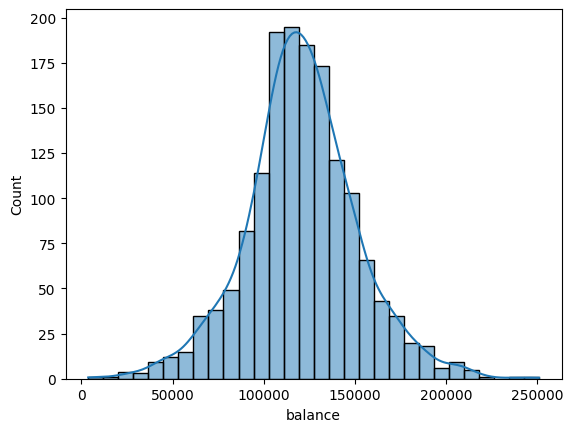

In [205]:
sns.histplot(data=saving_churn_customer_df, x='balance', bins=30, kde=True)

<Axes: xlabel='balance', ylabel='Count'>

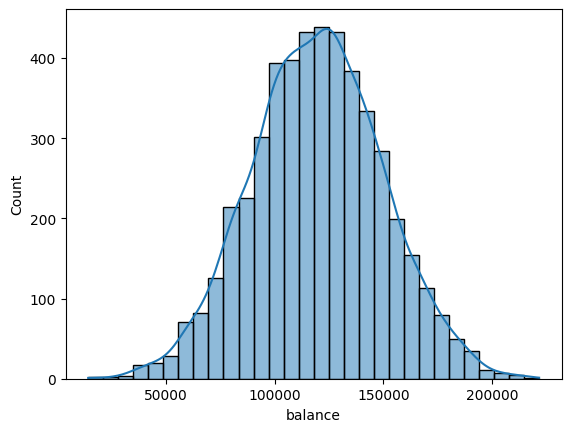

In [206]:
sns.histplot(data=saving_non_churn_customer_df, x='balance', bins=30, kde=True)

Since both follows bell-shaped, we are going for T-test. Before evaluating with T-Test, we will perform Levene's Test.

In [207]:
from scipy.stats import levene
saving_churn_group = saving_churn_customer_df["balance"]
saving_non_churn_group = saving_non_churn_customer_df["balance"]
levene_stat,p_val = levene(saving_churn_group, saving_non_churn_group)
print(f"Levene's test statistic: {levene_stat}, p-value: {p_val}")

Levene's test statistic: 2.945753863336243, p-value: 0.08615206557576904


p_value > 0.05
According to T test Results, saving doesn't impact much on churn.

In [208]:
income_churn_group = bank_account_df[bank_account_df['exited'] == 1]['estimatedsalary']
income_non_churn_group = bank_account_df[bank_account_df['exited'] == 0]['estimatedsalary']

<Axes: xlabel='estimatedsalary', ylabel='Count'>

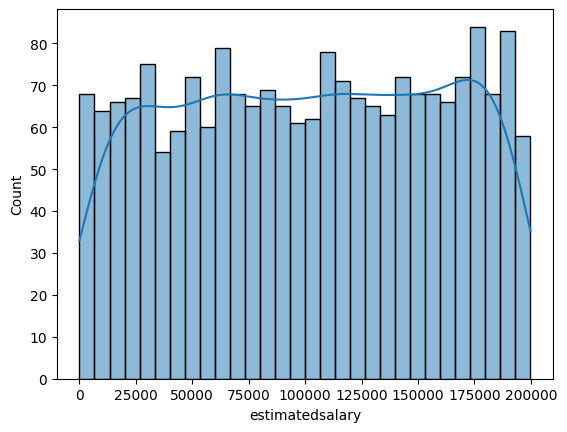

In [209]:
sns.histplot(income_churn_group, bins=30, kde=True)

<Axes: xlabel='estimatedsalary', ylabel='Count'>

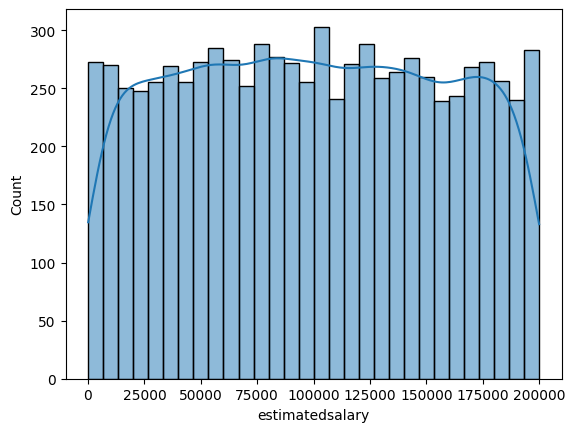

In [210]:
sns.histplot(income_non_churn_group, bins=30, kde=True)

In [211]:
from scipy.stats import mannwhitneyu
mannwhitneyu_stats, p_val = mannwhitneyu(income_churn_group, income_non_churn_group, alternative='two-sided')
print(f"Mann-Whitney U test statistic: {mannwhitneyu_stats}, p-value: {p_val}")

Mann-Whitney U test statistic: 8247444.0, p-value: 0.22778365666167566


According to Mann-Whitney Test Results, churners and non churners are not dependent on income as well.

In [212]:
from scipy.stats import ttest_ind

ttest_stat, p_value = ttest_ind(saving_churn_group, saving_non_churn_group)
print(f"t-test statistic: {ttest_stat}, p-value: {p_value}")

t-test statistic: 1.3798197713690539, p-value: 0.16769050368669355


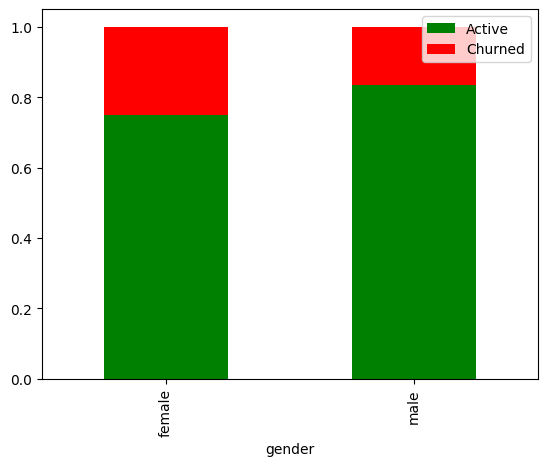

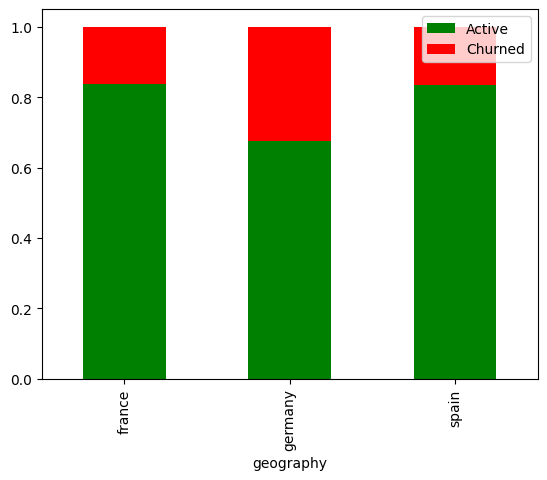

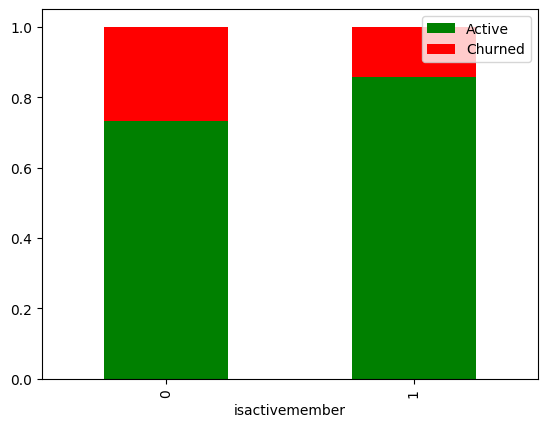

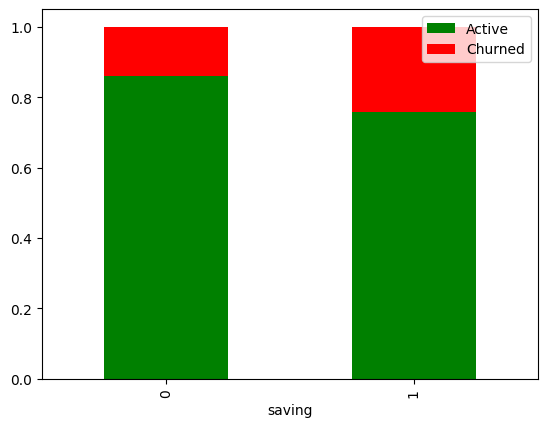

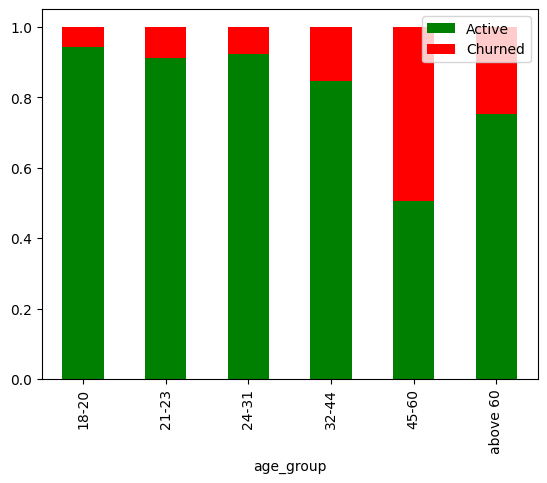

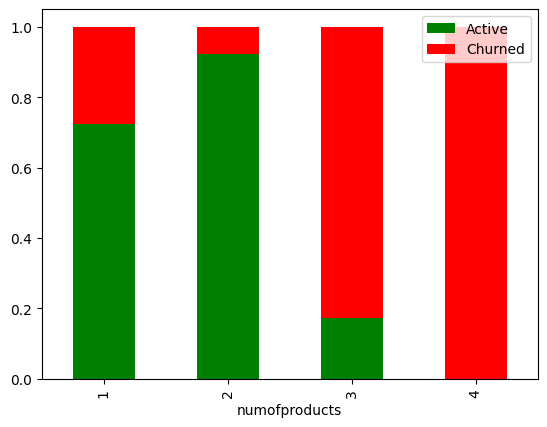

In [213]:
churn_categorical_columns = ['gender', 'geography', 'isactivemember', 'saving', 'age_group', 'numofproducts']

for col in churn_categorical_columns:
    ct = pd.crosstab(bank_account_df[col], bank_account_df['exited'], normalize='index')
    ct.plot(kind='bar', stacked=True, color=['green', 'red'])
    plt.legend(loc='upper right', labels=['Active', 'Churned'])
    plt.show()

In [214]:
contingency_table = {}

for col in churn_categorical_columns:
    contingency_table[col] = pd.crosstab(bank_account_df[col], bank_account_df['exited'])
    display(contingency_table[col])

exited,0,1
gender,,
female,3402,1139
male,4558,898


exited,0,1
geography,,
france,4203,810
germany,1694,814
spain,2063,413


exited,0,1
isactivemember,,
0,3546,1302
1,4414,735


exited,0,1
saving,,
0,3116,500
1,4844,1537


exited,0,1
age_group,,
18-20,84,5
21-23,215,21
24-31,1892,155
32-44,4473,812
45-60,947,929
above 60,349,115


exited,0,1
numofproducts,,
1,3672,1409
2,4242,348
3,46,220
4,0,60


In [215]:
from scipy.stats import chi2_contingency

chi2_results = []
for col in churn_categorical_columns:
    chi2_stats, chi2_p_val, dof, expected = chi2_contingency(contingency_table[col])
    chi2_results.append({'variable': col, 'chi2_statistic': chi2_stats, 'p_value': chi2_p_val})
chi2_results = pd.DataFrame(chi2_results)
chi2_results


,variable,chi2_statistic,p_value
0,gender,113.067532,2.085494e-26
1,geography,301.401921,3.559626e-66
2,isactivemember,242.859170,9.360390e-55
3,saving,149.113217,2.708901e-34
4,age_group,1307.473196,1.535561e-280
5,numofproducts,1503.947288,0.000000e+00


According to statiscal test and visual analysis, geography variable (germany) is most influence in churn rate. Inactive customers are more likely to exit than active customers. We need to provide credit plan to improve engagement and reduce churn. Females are more likely to exit(churn) than males.

In [216]:
from scipy.stats import chi2_contingency

chi2_results = []
for col in churn_categorical_columns:
    contingency_table = pd.crosstab(bank_account_df[col], bank_account_df['exited'])
    chi2_stat, p_val, dof, expected = chi2_contingency(contingency_table)
    chi2_results.append((col, chi2_stat, p_val))

### **Feature Engineering**

In [217]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scale_columns = ['numofproducts', 'creditscore', 'age']
for col in scale_columns:
    bank_account_df[col+'_scale'] = scaler.fit_transform(bank_account_df[[col]])

In [218]:
bank_account_df['numofproducts_scale'].unique()

array([0.        , 0.66666667, 0.33333333, 1.        ])

In [219]:
bank_account_df['gender_scale'] = bank_account_df['gender'].map({'male': 0, 'female': 1}).astype(int)

In [220]:
geography_dummies = pd.get_dummies(bank_account_df['geography'], prefix='geography', drop_first=True)
age_group_dummies = pd.get_dummies(bank_account_df['age_group'], prefix='age_group', drop_first=True)
numofproducts_dummies = pd.get_dummies(bank_account_df['numofproducts'], prefix='numofproducts', drop_first=False)

In [221]:
bank_account_df = pd.concat([bank_account_df, geography_dummies, age_group_dummies, numofproducts_dummies], axis=1)
bank_account_df.dtypes

balance                   float64
numofproducts               int64
hascrcard                   int64
tenure                      int64
isactivemember              int64
exited                      int64
creditscore                 int64
geography                  object
gender                     object
age                         int64
estimatedsalary           float64
estimatedsalary_group    category
age_group                category
saving                      int64
saving_group             category
creditscore_group        category
numofproducts_scale       float64
creditscore_scale         float64
age_scale                 float64
gender_scale                int64
geography_germany            bool
geography_spain              bool
age_group_21-23              bool
age_group_24-31              bool
age_group_32-44              bool
age_group_45-60              bool
age_group_above 60           bool
numofproducts_1              bool
numofproducts_2              bool
numofproducts_

In [222]:
bank_account_df[geography_dummies.columns] = bank_account_df[geography_dummies.columns].astype(int)
bank_account_df[age_group_dummies.columns] = bank_account_df[age_group_dummies.columns].astype(int)
bank_account_df[numofproducts_dummies.columns] = bank_account_df[numofproducts_dummies.columns].astype(int)

In [223]:
bank_account_df['exited'].value_counts()

exited
0    7960
1    2037
Name: count, dtype: int64

In [224]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,precision_recall_curve, roc_auc_score, confusion_matrix, classification_report

In [225]:
X = bank_account_df[[
    'numofproducts_1',
    'numofproducts_2',
    'numofproducts_3',
    'numofproducts_4',
    'creditscore_scale', 
    'age_group_21-23', 
    'age_group_24-31', 
    'age_group_32-44', 
    'age_group_45-60', 
    'age_group_above 60',
    'gender_scale', 
    'geography_germany', 
    'geography_spain',  
    'saving', 
    'isactivemember', 
    'hascrcard']]

In [226]:
y = bank_account_df['exited']

In [227]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [228]:
accuracy_list = []
precision_list = []
recall_list = []
f1_list = []

y_true_all = []
y_proba_all = []

In [229]:
from sklearn.linear_model import LogisticRegression
for train_index, test_index in kf.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model = LogisticRegression(class_weight='balanced')
    model.fit(X_train, y_train)
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= 0.59).astype(int)
    #y_pred = model.predict(X_test)

    y_true_all.extend(y_test)
    y_proba_all.extend(y_proba)

    accuracy_list.append(accuracy_score(y_test, y_pred))
    precision_list.append(precision_score(y_test, y_pred))
    recall_list.append(recall_score(y_test, y_pred))
    f1_list.append(f1_score(y_test, y_pred))

print(f"Average Accuracy: {np.mean(accuracy_list):.4f}")
print(f"Average Precision: {np.mean(precision_list):.4f}")
print(f"Average Recall: {np.mean(recall_list):.4f}")
print(f"Average F1 Score: {np.mean(f1_list):.4f}")

Average Accuracy: 0.8056
Average Precision: 0.5176
Average Recall: 0.6760
Average F1 Score: 0.5862


In [230]:
precision, recall, thresholds = precision_recall_curve(y_true_all, y_proba_all)

In [231]:
precision, recall, thresholds 

(array([0.20376113, 0.20378151, 0.2038019 , ..., 1.        , 1.        ,
        1.        ], shape=(9652,)),
 array([1.00000000e+00, 1.00000000e+00, 1.00000000e+00, ...,
        9.81836033e-04, 4.90918017e-04, 0.00000000e+00], shape=(9652,)),
 array([0.03013411, 0.03036485, 0.03040617, ..., 0.99834108, 0.99842636,
        0.99859039], shape=(9651,)))

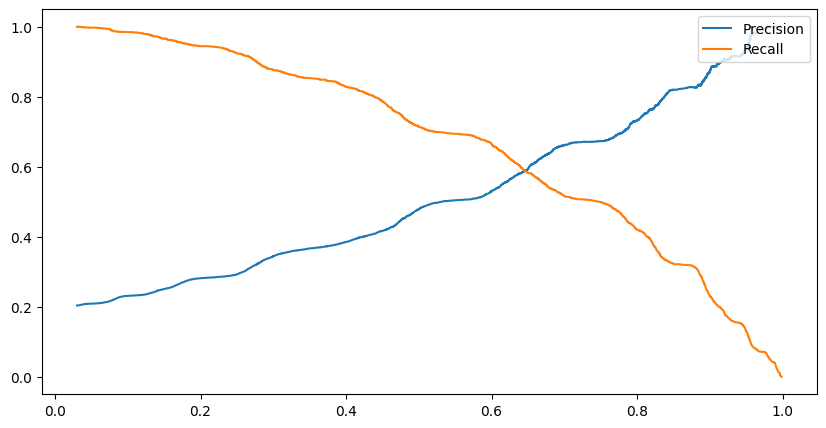

In [232]:
plt.figure(figsize=(10, 5))
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[1:], label='Recall')
plt.legend(loc = 'upper right')
plt.show()

In [233]:
f1_score = 2 * (precision * recall) / (precision + recall)
best_threshold = thresholds[np.argmax(f1_score)]
best_threshold

np.float64(0.6178058132433205)

In [234]:
pd.DataFrame({
    'Feature': X.columns, 
    'Coefficient': model.coef_[0]
    }).sort_values(by='Coefficient', ascending=False)

,Feature,Coefficient
3,numofproducts_4,2.567318
8,age_group_45-60,1.818551
2,numofproducts_3,1.586654
9,age_group_above 60,0.957328
11,geography_germany,0.848381
10,gender_scale,0.552304
7,age_group_32-44,0.174269
12,geography_spain,0.047901
13,saving,-0.005793
4,creditscore_scale,-0.267117


In [235]:
bank_account_df.to_csv('cleaned_data.csv')

In [236]:
import pandas as pd
from scipy.stats import chi2_contingency

df = pd.read_csv("cleaned_data.csv")
df.columns = [c.lower() for c in df.columns]

if "geography" in df.columns:
    df["geography"] = df["geography"].astype(str).str.lower().str.strip()
if "gender" in df.columns:
    df["gender"] = df["gender"].astype(str).str.lower().str.strip()
if "age_group" not in df.columns and "age" in df.columns:
    df["age_group"] = pd.cut(
        df["age"],
        bins=[17, 20, 23, 31, 44, 60, 120],
        labels=["18-20", "21-23", "24-31", "32-44", "45-60", "above 60"],
    )
if "creditscore_group" not in df.columns and "creditscore" in df.columns:
    df["creditscore_group"] = pd.cut(
        df["creditscore"],
        bins=[-float("inf"), 650, 700, 800, float("inf")],
        labels=["below 650", "650-700", "700-800", "above 800"],
        include_lowest=True,
    )
if "saving_group" not in df.columns and "balance" in df.columns:
    df["saving_group"] = pd.cut(
        df["balance"],
        bins=[-1, 0, 50000, 100000, 150000, 200000, 300000],
        labels=["no saving", "0-50k", "50k-100k", "100k-150k", "150k-200k", "above 200k"],
    )
if "estimatedsalary_group" not in df.columns and "estimatedsalary" in df.columns:
    df["estimatedsalary_group"] = pd.cut(
        df["estimatedsalary"],
        bins=[0, 1000, 20000, 50000, 100000, 150000, 200000, 400000],
        labels=["below 1k", "1k-20k", "20k-50k", "50k-100k", "100k-150k", "150k-200k", "above 200k"],
        right=False,
    )

candidates = [
    "geography",
    "gender",
    "age_group",
    "numofproducts",
    "tenure",
    "hascrcard",
    "isactivemember",
    "creditscore_group",
    "saving_group",
    "estimatedsalary_group",
]

results = []
for col in candidates:
    if col not in df.columns:
        continue
    ct = pd.crosstab(df[col], df["exited"])
    if ct.shape[0] < 2 or ct.shape[1] < 2:
        continue
    chi2, p, dof, exp = chi2_contingency(ct)
    results.append((col, p, chi2, dof))

results = pd.DataFrame(results, columns=["feature", "p_value", "chi2", "dof"]).sort_values("p_value")
results

,feature,p_value,chi2,dof
3,numofproducts,0.000000e+00,1503.947288,3
2,age_group,1.535561e-280,1307.473196,5
0,geography,3.559626e-66,301.401921,2
5,hascrcard,9.360390e-55,242.859170,1
6,isactivemember,9.360390e-55,242.859170,1
8,saving_group,1.036622e-41,202.046349,5
1,gender,2.085494e-26,113.067532,1
7,creditscore_group,4.994174e-02,7.817329,3
4,tenure,1.782949e-01,13.885154,10
9,estimatedsalary_group,7.489295e-01,2.681611,5
